# This is a sample Jupyter Notebook

Below is an example of a code cell. 
Put your cursor into the cell and press Shift+Enter to execute it and select the next one, or click 'Run Cell' button.

Press Double Shift to search everywhere for classes, files, tool windows, actions, and settings.

To learn more about Jupyter Notebooks in PyCharm, see [help](https://www.jetbrains.com/help/pycharm/ipython-notebook-support.html).
For an overview of PyCharm, go to Help -> Learn IDE features or refer to [our documentation](https://www.jetbrains.com/help/pycharm/getting-started.html).


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip
C:\Users\tmapillar\AppData\Local\Temp\ipykernel_39088\2934630086.py:85: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['analysis_date'] = pd.to_datetime(df['analysis_date'], errors='coerce')


Data loaded successfully. Shape: (33, 18)

Sample of the data:
  INDEX MEMBER NO  Gender  CURRENT AGE SERVICE DATE  \
0     0    125207  FEMALE           69   2025-09-15   
1     1    125207    MALE           62   2025-09-15   
2     2    128354    MALE           60   2025-09-13   
3     3    128354    MALE           60   2025-09-13   
4     4    128354  FEMALE           58   2025-09-13   

                                 CODE DESCRIPTION  \
0  ROSUCOR 20 (ROSUVASTATIN COATED TABLETS ) 20MG   
1  ROSUCOR 20 (ROSUVASTATIN COATED TABLETS ) 20MG   
2                                     VENEPUNTURE   
3                                FULL BLOOD COUNT   
4                                     VENEPUNTURE   

                                ICD10 DESCRIPTION  UNITS  AMOUNT CLAIMED  \
0                         DIAGNOSIS NOT SPECIFIED     28       11.212963   
1                         DIAGNOSIS NOT SPECIFIED     28       11.212963   
2  ACUTE UPPER RESPIRATORY INFECTION, UNSPECIFIED      1   

<Figure size 1200x600 with 0 Axes>

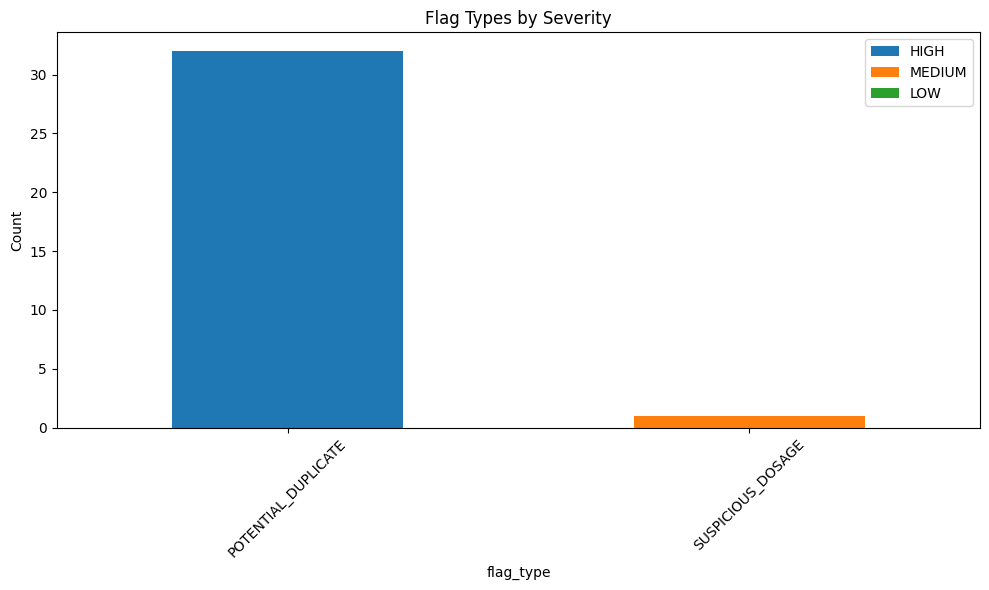

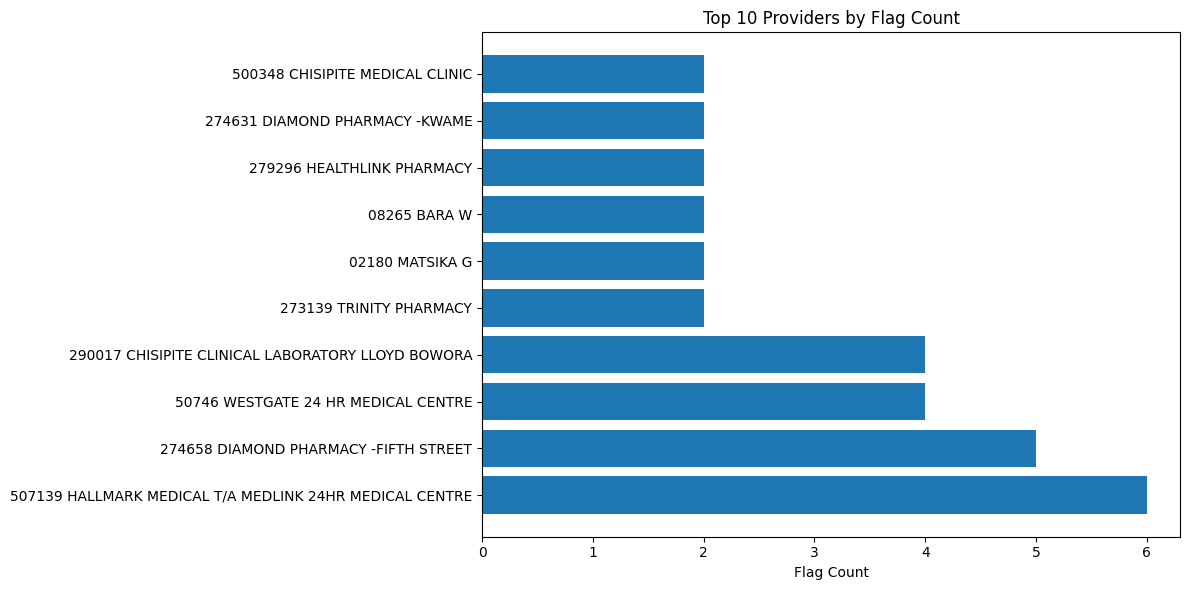


Total duplicate claims: 32

Members with most duplicate claims:
MEMBER NO
128354    6
144380    6
147931    4
133460    4
125207    2
131896    2
141335    2
149326    2
160973    2
166299    2
dtype: int64

Providers with most duplicate claims:
PROVIDER NAME
507139 HALLMARK MEDICAL T/A MEDLINK 24HR MEDICAL CENTRE    6
274658 DIAMOND PHARMACY -FIFTH STREET                      4
50746 WESTGATE 24 HR MEDICAL CENTRE                        4
290017 CHISIPITE CLINICAL LABORATORY LLOYD BOWORA          4
273139 TRINITY PHARMACY                                    2
02180 MATSIKA G                                            2
08265 BARA W                                               2
279296 HEALTHLINK PHARMACY                                 2
274631 DIAMOND PHARMACY -KWAME                             2
500348 CHISIPITE MEDICAL CLINIC                            2
dtype: int64

All Flagged Claims:


,MEMBER NO,SERVICE DATE,CODE DESCRIPTION,PROVIDER NAME,AMOUNT CLAIMED,TOTAL PAID,flag_type,severity,flag_description,flag_details
0,125207,2025-09-15,ROSUCOR 20 (ROSUVASTATIN COATED TABLETS ) 20MG,274631 DIAMOND PHARMACY -KWAME,11.212963,11.212963,POTENTIAL_DUPLICATE,HIGH,Potential duplicate claim for same service on ...,"Member 125207, Date 2025-09-15, Service: ROSUC..."
1,125207,2025-09-15,ROSUCOR 20 (ROSUVASTATIN COATED TABLETS ) 20MG,274631 DIAMOND PHARMACY -KWAME,11.212963,11.212963,POTENTIAL_DUPLICATE,HIGH,Potential duplicate claim for same service on ...,"Member 125207, Date 2025-09-15, Service: ROSUC..."
2,128354,2025-09-13,VENEPUNTURE,290017 CHISIPITE CLINICAL LABORATORY LLOYD BOWORA,13.333333,9.686296,POTENTIAL_DUPLICATE,HIGH,Potential duplicate claim for same service on ...,"Member 128354, Date 2025-09-13, Service: VENEP..."
3,128354,2025-09-13,FULL BLOOD COUNT,290017 CHISIPITE CLINICAL LABORATORY LLOYD BOWORA,46.666667,28.029259,POTENTIAL_DUPLICATE,HIGH,Potential duplicate claim for same service on ...,"Member 128354, Date 2025-09-13, Service: FULL ..."
4,128354,2025-09-13,VENEPUNTURE,290017 CHISIPITE CLINICAL LABORATORY LLOYD BOWORA,13.333333,9.686296,POTENTIAL_DUPLICATE,HIGH,Potential duplicate claim for same service on ...,"Member 128354, Date 2025-09-13, Service: VENEP..."
5,128354,2025-09-13,FULL BLOOD COUNT,290017 CHISIPITE CLINICAL LABORATORY LLOYD BOWORA,46.666667,28.029259,POTENTIAL_DUPLICATE,HIGH,Potential duplicate claim for same service on ...,"Member 128354, Date 2025-09-13, Service: FULL ..."
6,128354,2025-09-13,"NON EMERGENCY/OUTPATIENT, INITIAL CONSULTATION",500348 CHISIPITE MEDICAL CLINIC,58.116667,37.676296,POTENTIAL_DUPLICATE,HIGH,Potential duplicate claim for same service on ...,"Member 128354, Date 2025-09-13, Service: NON E..."
7,128354,2025-09-13,"NON EMERGENCY/OUTPATIENT, INITIAL CONSULTATION",500348 CHISIPITE MEDICAL CLINIC,58.116667,37.676296,POTENTIAL_DUPLICATE,HIGH,Potential duplicate claim for same service on ...,"Member 128354, Date 2025-09-13, Service: NON E..."
8,130064,2025-09-09,VIRADAY(TENOF300/EMTRI200/EFAV600MG) 30S,274658 DIAMOND PHARMACY -FIFTH STREET,19.444444,19.444444,SUSPICIOUS_DOSAGE,MEDIUM,Unusual round dosage number (600.0mg),"Dosage 600.0mg, Medication: VIRADAY(TENOF300/E..."
9,131896,2025-09-26,INITIAL CONSULTATION BY REGISTERED GENERAL NURSE,62809 ARMSPACK ENTERPRISES T/A NORTH & MIDDLE ...,18.148148,12.984815,POTENTIAL_DUPLICATE,HIGH,Potential duplicate claim for same service on ...,"Member 131896, Date 2025-09-26, Service: INITI..."


In [2]:

# =============================================================================
# FRAUD, WASTE, AND ABUSE (FWA) DETECTION MODEL
# =============================================================================

# Install required libraries if not already installed
!pip install pandas openpyxl matplotlib -q

# Import necessary libraries
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt
import re
import io

# =============================================================================
# DATA LOADING AND PREPROCESSING
# =============================================================================

# Create the data from your provided text
data = """
0 | 125207 | FEMALE | 69 | 2025-09-15 | ROSUCOR 20 (ROSUVASTATIN COATED TABLETS ) 20MG | DIAGNOSIS NOT SPECIFIED | 28 | 11.21296296 | 11.21296296 | MEDICATION - CHRONIC | 274631 DIAMOND PHARMACY -KWAME | MULHOLLAND TRADERS PVT LTD (MEDGEN) | POTENTIAL_DUPLICATE | HIGH | Potential duplicate claim for same service on same date | Member 125207, Date 2025-09-15, Service: ROSUCOR 20 (ROSUVASTATIN COATED TABLETS ) 20MG | 2025-10-28 09:52:24 |
1 | 125207 | MALE | 62 | 2025-09-15 | ROSUCOR 20 (ROSUVASTATIN COATED TABLETS ) 20MG | DIAGNOSIS NOT SPECIFIED | 28 | 11.21296296 | 11.21296296 | MEDICATION - CHRONIC | 274631 DIAMOND PHARMACY -KWAME | MULHOLLAND TRADERS PVT LTD (MEDGEN) | POTENTIAL_DUPLICATE | HIGH | Potential duplicate claim for same service on same date | Member 125207, Date 2025-09-15, Service: ROSUCOR 20 (ROSUVASTATIN COATED TABLETS ) 20MG | 2025-10-28 09:52:24 |
2 | 128354 | MALE | 60 | 2025-09-13 | VENEPUNTURE | ACUTE UPPER RESPIRATORY INFECTION, UNSPECIFIED | 1 | 13.33333333 | 9.686296296 | PATHOLOGY | 290017 CHISIPITE CLINICAL LABORATORY LLOYD BOWORA | FINEART TECHNOLOGIES (PVT) LTD | POTENTIAL_DUPLICATE | HIGH | Potential duplicate claim for same service on same date | Member 128354, Date 2025-09-13, Service: VENEPUNTURE | 2025-10-28 09:52:24 |
3 | 128354 | MALE | 60 | 2025-09-13 | FULL BLOOD COUNT | ACUTE UPPER RESPIRATORY INFECTION, UNSPECIFIED | 1 | 46.66666667 | 28.02925926 | PATHOLOGY | 290017 CHISIPITE CLINICAL LABORATORY LLOYD BOWORA | FINEART TECHNOLOGIES (PVT) LTD | POTENTIAL_DUPLICATE | HIGH | Potential duplicate claim for same service on same date | Member 128354, Date 2025-09-13, Service: FULL BLOOD COUNT | 2025-10-28 09:52:24 |
4 | 128354 | FEMALE | 58 | 2025-09-13 | VENEPUNTURE | UNSPECIFIED DEMENTIA | 1 | 13.33333333 | 9.686296296 | PATHOLOGY | 290017 CHISIPITE CLINICAL LABORATORY LLOYD BOWORA | FINEART TECHNOLOGIES (PVT) LTD | POTENTIAL_DUPLICATE | HIGH | Potential duplicate claim for same service on same date | Member 128354, Date 2025-09-13, Service: VENEPUNTURE | 2025-10-28 09:52:24 |
5 | 128354 | FEMALE | 58 | 2025-09-13 | FULL BLOOD COUNT | UNSPECIFIED DEMENTIA | 1 | 46.66666667 | 28.02925926 | PATHOLOGY | 290017 CHISIPITE CLINICAL LABORATORY LLOYD BOWORA | FINEART TECHNOLOGIES (PVT) LTD | POTENTIAL_DUPLICATE | HIGH | Potential duplicate claim for same service on same date | Member 128354, Date 2025-09-13, Service: FULL BLOOD COUNT | 2025-10-28 09:52:24 |
6 | 128354 | MALE | 60 | 2025-09-13 | NON EMERGENCY/OUTPATIENT, INITIAL CONSULTATION | ACUTE UPPER RESPIRATORY INFECTION, UNSPECIFIED | 1 | 58.11666667 | 37.6762963 | CONSULTATIONS - GP | 500348 CHISIPITE MEDICAL CLINIC | FINEART TECHNOLOGIES (PVT) LTD | POTENTIAL_DUPLICATE | HIGH | Potential duplicate claim for same service on same date | Member 128354, Date 2025-09-13, Service: NON EMERGENCY/OUTPATIENT, INITIAL CONSULTATION | 2025-10-28 09:52:24 |
7 | 128354 | FEMALE | 58 | 2025-09-13 | NON EMERGENCY/OUTPATIENT, INITIAL CONSULTATION | DEMENTIA IN OTHER SPECIFIED DISEASES CLASSIFIED ELSEWHERE | 1 | 58.11666667 | 37.6762963 | CONSULTATIONS - GP | 500348 CHISIPITE MEDICAL CLINIC | FINEART TECHNOLOGIES (PVT) LTD | POTENTIAL_DUPLICATE | HIGH | Potential duplicate claim for same service on same date | Member 128354, Date 2025-09-13, Service: NON EMERGENCY/OUTPATIENT, INITIAL CONSULTATION | 2025-10-28 09:52:24 |
8 | 130064 | FEMALE | 53 | 2025-09-09 | VIRADAY(TENOF300/EMTRI200/EFAV600MG) 30S | DIAGNOSIS NOT SPECIFIED | 30 | 19.44444444 | 19.44444444 | MEDICATION - ART | 274658 DIAMOND PHARMACY -FIFTH STREET | *** INSURER (72) SELF PAYING *** | SUSPICIOUS_DOSAGE | MEDIUM | Unusual round dosage number (600.0mg) | Dosage 600.0mg, Medication: VIRADAY(TENOF300/EMTRI200/EFAV600MG) 30S | 2025-10-28 09:52:24 |
9 | 131896 | MALE | 5 | 2025-09-26 | INITIAL CONSULTATION BY REGISTERED GENERAL NURSE | COUGH | 1 | 18.14814815 | 12.98481481 | CONSULTATIONS - GP | 62809 ARMSPACK ENTERPRISES T/A NORTH & MIDDLE DYKE CLINIC | ZIMASCO (PVT) LTD - SHURUGWI | POTENTIAL_DUPLICATE | HIGH | Potential duplicate claim for same service on same date | Member 131896, Date 2025-09-26, Service: INITIAL CONSULTATION BY REGISTERED GENERAL NURSE | 2025-10-28 09:52:24 |
10 | 131896 | FEMALE | 10 | 2025-09-26 | INITIAL CONSULTATION BY REGISTERED GENERAL NURSE | SALMONELLA ENTERITIS | 1 | 18.14814815 | 12.98481481 | CONSULTATIONS - GP | 62809 ARMSPACK ENTERPRISES T/A NORTH & MIDDLE DYKE CLINIC | ZIMASCO (PVT) LTD - SHURUGWI | POTENTIAL_DUPLICATE | HIGH | Potential duplicate claim for same service on same date | Member 131896, Date 2025-09-26, Service: INITIAL CONSULTATION BY REGISTERED GENERAL NURSE | 2025-10-28 09:52:24 |
11 | 133460 | FEMALE | 61 | 2025-09-09 | RANOPHAGE (METFORMIN HYDROCHLORIDE MODIFIED RELEASE) 1G 30S | DIAGNOSIS NOT SPECIFIED | 30 | 10.11111111 | 10.11111111 | MEDICATION - CHRONIC | 274658 DIAMOND PHARMACY -FIFTH STREET | *** INSURER (72) SELF PAYING *** | POTENTIAL_DUPLICATE | HIGH | Potential duplicate claim for same service on same date | Member 133460, Date 2025-09-09, Service: RANOPHAGE (METFORMIN HYDROCHLORIDE MODIFIED RELEASE) 1G 30S | 2025-10-28 09:52:24 |
12 | 133460 | FEMALE | 61 | 2025-09-09 | LIPITOR(ATORVASTATIN) 10MG TABLETS | DIAGNOSIS NOT SPECIFIED | 30 | 9.774074074 | 9.774074074 | MEDICATION - CHRONIC | 274658 DIAMOND PHARMACY -FIFTH STREET | *** INSURER (72) SELF PAYING *** | POTENTIAL_DUPLICATE | HIGH | Potential duplicate claim for same service on same date | Member 133460, Date 2025-09-09, Service: LIPITOR(ATORVASTATIN) 10MG TABLETS | 2025-10-28 09:52:24 |
13 | 133460 | MALE | 65 | 2025-09-09 | RANOPHAGE (METFORMIN HYDROCHLORIDE MODIFIED RELEASE) 1G 30S | DIAGNOSIS NOT SPECIFIED | 30 | 10.11111111 | 0 | MEDICATION - CHRONIC | 274658 DIAMOND PHARMACY -FIFTH STREET | *** INSURER (72) SELF PAYING *** | POTENTIAL_DUPLICATE | HIGH | Potential duplicate claim for same service on same date | Member 133460, Date 2025-09-09, Service: RANOPHAGE (METFORMIN HYDROCHLORIDE MODIFIED RELEASE) 1G 30S | 2025-10-28 09:52:24 |
14 | 133460 | MALE | 65 | 2025-09-09 | LIPITOR(ATORVASTATIN) 10MG TABLETS | DIAGNOSIS NOT SPECIFIED | 30 | 9.774074074 | 0 | MEDICATION - CHRONIC | 274658 DIAMOND PHARMACY -FIFTH STREET | *** INSURER (72) SELF PAYING *** | POTENTIAL_DUPLICATE | HIGH | Potential duplicate claim for same service on same date | Member 133460, Date 2025-09-09, Service: LIPITOR(ATORVASTATIN) 10MG TABLETS | 2025-10-28 09:52:24 |
15 | 141335 | FEMALE | 62 | 2025-08-14 | INITIAL CONSULTATION AT ROOMS | ACUTE NASOPHARYNGITIS [COMMON COLD] | 1 | 33.33333333 | 25.9637037 | CONSULTATIONS - GP | 02180 MATSIKA G | *** INSURER (72) SELF PAYING *** | POTENTIAL_DUPLICATE | HIGH | Potential duplicate claim for same service on same date | Member 141335, Date 2025-08-14, Service: INITIAL CONSULTATION AT ROOMS | 2025-10-28 09:52:24 |
16 | 141335 | MALE | 66 | 2025-08-14 | INITIAL CONSULTATION AT ROOMS | UNSPECIFIED DIABETES MELLITUS | 1 | 33.33333333 | 25.9637037 | CONSULTATIONS - GP | 02180 MATSIKA G | *** INSURER (72) SELF PAYING *** | POTENTIAL_DUPLICATE | HIGH | Potential duplicate claim for same service on same date | Member 141335, Date 2025-08-14, Service: INITIAL CONSULTATION AT ROOMS | 2025-10-28 09:52:24 |
17 | 144380 | FEMALE | 5 | 2025-08-13 | WEEKDAYS 7AM TO 7PM, ATTENDANCE, INCLUDING CONSULTATION AND TREATMENT 16 TO 45 MINUTES, PER ATTENDAN | ACUTE UPPER RESPIRATORY INFECTION, UNSPECIFIED | 1 | 62.03703704 | 62.03703704 | EMERGENCY CASUALTY TREATMENT | 507139 HALLMARK MEDICAL T/A MEDLINK 24HR MEDICAL CENTRE | *** INSURER (72) SELF PAYING *** | POTENTIAL_DUPLICATE | HIGH | Potential duplicate claim for same service on same date | Member 144380, Date 2025-08-13, Service: WEEKDAYS 7AM TO 7PM, ATTENDANCE, INCLUDING CONSULTATION AND TREATMENT 16 TO 45 MINUTES, PER ATTENDAN | 2025-10-28 09:52:24 |
18 | 144380 | FEMALE | 5 | 2025-08-13 | VENEPUNTURE, INTRAVENOUS INFUSION OVER 3 YEARS | ACUTE UPPER RESPIRATORY INFECTION, UNSPECIFIED | 1 | 7.407407407 | 7.407407407 | HOSPITALISATION | 507139 HALLMARK MEDICAL T/A MEDLINK 24HR MEDICAL CENTRE | *** INSURER (72) SELF PAYING *** | POTENTIAL_DUPLICATE | HIGH | Potential duplicate claim for same service on same date | Member 144380, Date 2025-08-13, Service: VENEPUNTURE, INTRAVENOUS INFUSION OVER 3 YEARS | 2025-10-28 09:52:24 |
19 | 144380 | FEMALE | 6 | 2025-08-13 | WEEKDAYS 7AM TO 7PM, ATTENDANCE, INCLUDING CONSULTATION AND TREATMENT 16 TO 45 MINUTES, PER ATTENDAN | ACUTE UPPER RESPIRATORY INFECTION, UNSPECIFIED | 1 | 62.03703704 | 62.03703704 | EMERGENCY CASUALTY TREATMENT | 507139 HALLMARK MEDICAL T/A MEDLINK 24HR MEDICAL CENTRE | *** INSURER (72) SELF PAYING *** | POTENTIAL_DUPLICATE | HIGH | Potential duplicate claim for same service on same date | Member 144380, Date 2025-08-13, Service: WEEKDAYS 7AM TO 7PM, ATTENDANCE, INCLUDING CONSULTATION AND TREATMENT 16 TO 45 MINUTES, PER ATTENDAN | 2025-10-28 09:52:24 |
20 | 144380 | FEMALE | 6 | 2025-08-13 | VENEPUNTURE, INTRAVENOUS INFUSION OVER 3 YEARS | ACUTE UPPER RESPIRATORY INFECTION, UNSPECIFIED | 1 | 7.407407407 | 7.407407407 | HOSPITALISATION | 507139 HALLMARK MEDICAL T/A MEDLINK 24HR MEDICAL CENTRE | *** INSURER (72) SELF PAYING *** | POTENTIAL_DUPLICATE | HIGH | Potential duplicate claim for same service on same date | Member 144380, Date 2025-08-13, Service: VENEPUNTURE, INTRAVENOUS INFUSION OVER 3 YEARS | 2025-10-28 09:52:24 |
21 | 144380 | FEMALE | 6 | 2025-08-13 | ACCIDENT AND EMERGENCY UNIT (INCLUDING OUTPATIENT DEPARTMENT) | ACUTE UPPER RESPIRATORY INFECTION, UNSPECIFIED | 3 | 15.37037037 | 2.9 | EMERGENCY CASUALTY TREATMENT | 507139 HALLMARK MEDICAL T/A MEDLINK 24HR MEDICAL CENTRE | *** INSURER (72) SELF PAYING *** | POTENTIAL_DUPLICATE | HIGH | Potential duplicate claim for same service on same date | Member 144380, Date 2025-08-13, Service: ACCIDENT AND EMERGENCY UNIT (INCLUDING OUTPATIENT DEPARTMENT) | 2025-10-28 09:52:24 |
22 | 144380 | FEMALE | 5 | 2025-08-13 | ACCIDENT AND EMERGENCY UNIT (INCLUDING OUTPATIENT DEPARTMENT) | ACUTE UPPER RESPIRATORY INFECTION, UNSPECIFIED | 3 | 15.37037037 | 2.954814815 | EMERGENCY CASUALTY TREATMENT | 507139 HALLMARK MEDICAL T/A MEDLINK 24HR MEDICAL CENTRE | *** INSURER (72) SELF PAYING *** | POTENTIAL_DUPLICATE | HIGH | Potential duplicate claim for same service on same date | Member 144380, Date 2025-08-13, Service: ACCIDENT AND EMERGENCY UNIT (INCLUDING OUTPATIENT DEPARTMENT) | 2025-10-28 09:52:24 |
23 | 147931 | FEMALE | 44 | 2025-08-12 | ACCIDENT AND EMERGENCY UNIT (INCLUDING OUTPATIENT DEPARTMENT) | ACUTE UPPER RESPIRATORY INFECTION, UNSPECIFIED | 2 | 16.66666667 | 0 | EMERGENCY CASUALTY TREATMENT | 50746 WESTGATE 24 HR MEDICAL CENTRE | *** INSURER (72) SELF PAYING *** | POTENTIAL_DUPLICATE | HIGH | Potential duplicate claim for same service on same date | Member 147931, Date 2025-08-12, Service: ACCIDENT AND EMERGENCY UNIT (INCLUDING OUTPATIENT DEPARTMENT) | 2025-10-28 09:52:24 |
24 | 147931 | FEMALE | 7 | 2025-08-12 | ACCIDENT AND EMERGENCY UNIT (INCLUDING OUTPATIENT DEPARTMENT) | ACUTE UPPER RESPIRATORY INFECTION, UNSPECIFIED | 2 | 16.66666667 | 16.66666667 | EMERGENCY CASUALTY TREATMENT | 50746 WESTGATE 24 HR MEDICAL CENTRE | *** INSURER (72) SELF PAYING *** | POTENTIAL_DUPLICATE | HIGH | Potential duplicate claim for same service on same date | Member 147931, Date 2025-08-12, Service: ACCIDENT AND EMERGENCY UNIT (INCLUDING OUTPATIENT DEPARTMENT) | 2025-10-28 09:52:24 |
25 | 147931 | FEMALE | 7 | 2025-08-12 | ACCIDENT AND EMERGENCY UNIT (INCLUDING OUTPATIENT DEPARTMENT) SURGICAL SUNDRIES | ACUTE UPPER RESPIRATORY INFECTION, UNSPECIFIED | 2 | 1 | 1 | EMERGENCY CASUALTY TREATMENT | 50746 WESTGATE 24 HR MEDICAL CENTRE | *** INSURER (72) SELF PAYING *** | POTENTIAL_DUPLICATE | HIGH | Potential duplicate claim for same service on same date | Member 147931, Date 2025-08-12, Service: ACCIDENT AND EMERGENCY UNIT (INCLUDING OUTPATIENT DEPARTMENT) SURGICAL SUNDRIES | 2025-10-28 09:52:24 |
26 | 147931 | FEMALE | 44 | 2025-08-12 | ACCIDENT AND EMERGENCY UNIT (INCLUDING OUTPATIENT DEPARTMENT) SURGICAL SUNDRIES | ACUTE UPPER RESPIRATORY INFECTION, UNSPECIFIED | 2 | 1 | 0 | EMERGENCY CASUALTY TREATMENT | 50746 WESTGATE 24 HR MEDICAL CENTRE | *** INSURER (72) SELF PAYING *** | POTENTIAL_DUPLICATE | HIGH | Potential duplicate claim for same service on same date | Member 147931, Date 2025-08-12, Service: ACCIDENT AND EMERGENCY UNIT (INCLUDING OUTPATIENT DEPARTMENT) SURGICAL SUNDRIES | 2025-10-28 09:52:24 |
27 | 149326 | MALE | 68 | 2025-09-12 | INITIAL CONSULTATION AT ROOMS | SECONDARY HYPERTENSION | 1 | 48.77777778 | 22.66592593 | CONSULTATIONS - GP | 08265 BARA W | *** INSURER (72) SELF PAYING *** | POTENTIAL_DUPLICATE | HIGH | Potential duplicate claim for same service on same date | Member 149326, Date 2025-09-12, Service: INITIAL CONSULTATION AT ROOMS | 2025-10-28 09:52:24 |
28 | 149326 | FEMALE | 71 | 2025-09-12 | INITIAL CONSULTATION AT ROOMS | PAROSMIA | 1 | 48.77777778 | 22.66592593 | CONSULTATIONS - GP | 08265 BARA W | *** INSURER (72) SELF PAYING *** | POTENTIAL_DUPLICATE | HIGH | Potential duplicate claim for same service on same date | Member 149326, Date 2025-09-12, Service: INITIAL CONSULTATION AT ROOMS | 2025-10-28 09:52:24 |
29 | 160973 | FEMALE | 66 | 2025-09-03 | ROSUCOR (ROSUVASTATIN COATED TABLETS) 10MG 30S | DIAGNOSIS NOT SPECIFIED | 30 | 13.66666667 | 10.96666667 | MEDICATION - ACUTE | 273139 TRINITY PHARMACY | *** INSURER (72) SELF PAYING *** | POTENTIAL_DUPLICATE | HIGH | Potential duplicate claim for same service on same date | Member 160973, Date 2025-09-03, Service: ROSUCOR (ROSUVASTATIN COATED TABLETS) 10MG 30S | 2025-10-28 09:52:24 |
30 | 160973 | FEMALE | 66 | 2025-09-03 | ROSUCOR (ROSUVASTATIN COATED TABLETS) 10MG 30S | DIAGNOSIS NOT SPECIFIED | 30 | 13.66666667 | 10.96666667 | MEDICATION - ACUTE | 273139 TRINITY PHARMACY | *** INSURER (72) SELF PAYING *** | POTENTIAL_DUPLICATE | HIGH | Potential duplicate claim for same service on same date | Member 160973, Date 2025-09-03, Service: ROSUCOR (ROSUVASTATIN COATED TABLETS) 10MG 30S | 2025-10-28 09:52:24 |
31 | 166299 | FEMALE | 6 | 2025-09-02 | AMOCILLIN SUSPENSION | DIAGNOSIS NOT SPECIFIED | 100 | 6.666666667 | 6.666666667 | MEDICATION - ACUTE | 279296 HEALTHLINK PHARMACY | EXCEL ELEVATORS | POTENTIAL_DUPLICATE | HIGH | Potential duplicate claim for same service on same date | Member 166299, Date 2025-09-02, Service: AMOCILLIN SUSPENSION | 2025-10-28 09:52:24 |
32 | 166299 | FEMALE | 5 | 2025-09-02 | AMOCILLIN SUSPENSION | DIAGNOSIS NOT SPECIFIED | 100 | 6.666666667 | 6.666666667 | MEDICATION - ACUTE | 279296 HEALTHLINK PHARMACY | EXCEL ELEVATORS | POTENTIAL_DUPLICATE | HIGH | Potential duplicate claim for same service on same date | Member 166299, Date 2025-09-02, Service: AMOCILLIN SUSPENSION | 2025-10-28 09:52:24 |
"""

# Clean and parse the data
lines = data.strip().split('\n')
parsed_data = []

for line in lines:
    parts = line.split(' | ')
    # Remove empty strings and strip whitespace
    parts = [p.strip() for p in parts if p.strip()]
    if len(parts) >= 16:  # Ensure we have all columns
        parsed_data.append(parts)

# Create column names
columns = [
    'INDEX', 'MEMBER NO', 'Gender', 'CURRENT AGE', 'SERVICE DATE', 'CODE DESCRIPTION',
    'ICD10 DESCRIPTION', 'UNITS', 'AMOUNT CLAIMED', 'TOTAL PAID', 'BASE BENEFIT DESCRIPTION',
    'PROVIDER NAME', 'PAYER NAME', 'flag_type', 'severity', 'flag_description',
    'flag_details', 'analysis_date'
]

# Create DataFrame
df = pd.DataFrame(parsed_data, columns=columns)

# Convert numeric columns
numeric_cols = ['CURRENT AGE', 'UNITS', 'AMOUNT CLAIMED', 'TOTAL PAID']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Convert date columns
df['SERVICE DATE'] = pd.to_datetime(df['SERVICE DATE'], errors='coerce')
df['analysis_date'] = pd.to_datetime(df['analysis_date'], errors='coerce')

print("Data loaded successfully. Shape:", df.shape)
print("\nSample of the data:")
print(df.head())

# =============================================================================
# FWA DETECTION MODEL
# =============================================================================

def create_fwa_model(df):
    # Make a copy to avoid modifying the original
    claims_df = df.copy()

    # Initialize flag columns if they don't exist
    if 'flag_type' not in claims_df.columns:
        claims_df['flag_type'] = ''
        claims_df['severity'] = ''
        claims_df['flag_description'] = ''
        claims_df['flag_details'] = ''
        claims_df['analysis_date'] = datetime.now().strftime('%Y-%m-%d %H:%M:%S')

    # Rule 1: Duplicate Claims Detection
    duplicate_mask = claims_df.duplicated(subset=['MEMBER NO', 'SERVICE DATE', 'CODE DESCRIPTION'], keep=False)
    claims_df.loc[duplicate_mask, 'flag_type'] = 'POTENTIAL_DUPLICATE'
    claims_df.loc[duplicate_mask, 'severity'] = 'HIGH'
    claims_df.loc[duplicate_mask, 'flag_description'] = 'Potential duplicate claim for same service on same date'
    claims_df.loc[duplicate_mask, 'flag_details'] = claims_df.apply(
        lambda x: f"Member {x['MEMBER NO']}, Date {x['SERVICE DATE'].date()}, Service: {x['CODE DESCRIPTION']}",
        axis=1
    )

    # Rule 2: Suspicious Dosage Detection
    suspicious_dosage_mask = claims_df['CODE DESCRIPTION'].str.contains(r'\b\d+\.0+mg\b', regex=True, na=False)
    claims_df.loc[suspicious_dosage_mask & (claims_df['flag_type'] == ''), 'flag_type'] = 'SUSPICIOUS_DOSAGE'
    claims_df.loc[suspicious_dosage_mask & (claims_df['flag_type'] == ''), 'severity'] = 'MEDIUM'
    claims_df.loc[suspicious_dosage_mask & (claims_df['flag_type'] == ''), 'flag_description'] = 'Unusual round dosage number'
    claims_df.loc[suspicious_dosage_mask & (claims_df['flag_type'] == ''), 'flag_details'] = claims_df.apply(
        lambda x: f"Dosage extracted from {x['CODE DESCRIPTION']}",
        axis=1
    )

    # Rule 3: Unpaid Claims Detection
    unpaid_mask = (claims_df['AMOUNT CLAIMED'] > 0) & (claims_df['TOTAL PAID'] == 0)
    claims_df.loc[unpaid_mask & (claims_df['flag_type'] == ''), 'flag_type'] = 'UNPAID_CLAIM'
    claims_df.loc[unpaid_mask & (claims_df['flag_type'] == ''), 'severity'] = 'MEDIUM'
    claims_df.loc[unpaid_mask & (claims_df['flag_type'] == ''), 'flag_description'] = 'Claim submitted but not paid'
    claims_df.loc[unpaid_mask & (claims_df['flag_type'] == ''), 'flag_details'] = claims_df.apply(
        lambda x: f"Amount claimed: {x['AMOUNT CLAIMED']}, Amount paid: {x['TOTAL PAID']}",
        axis=1
    )

    # Rule 4: Same-Day Multiple Provider Detection
    member_date_provider = claims_df.groupby(['MEMBER NO', 'SERVICE DATE'])['PROVIDER NAME'].nunique()
    multi_provider_mask = claims_df.set_index(['MEMBER NO', 'SERVICE DATE']).index.map(
        lambda x: member_date_provider[x] > 1
    )
    claims_df.loc[multi_provider_mask & (claims_df['flag_type'] == ''), 'flag_type'] = 'MULTIPLE_PROVIDERS_SAME_DAY'
    claims_df.loc[multi_provider_mask & (claims_df['flag_type'] == ''), 'severity'] = 'MEDIUM'
    claims_df.loc[multi_provider_mask & (claims_df['flag_type'] == ''), 'flag_description'] = 'Member saw multiple providers on same day'
    claims_df.loc[multi_provider_mask & (claims_df['flag_type'] == ''), 'flag_details'] = claims_df.apply(
        lambda x: f"Member {x['MEMBER NO']} saw multiple providers on {x['SERVICE DATE'].date()}",
        axis=1
    )

    # Rule 5: High-Frequency Provider Detection
    provider_counts = claims_df['PROVIDER NAME'].value_counts()
    high_freq_threshold = provider_counts.quantile(0.9)  # Top 10% of providers by claim count
    high_freq_providers = provider_counts[provider_counts >= high_freq_threshold].index
    high_freq_mask = claims_df['PROVIDER NAME'].isin(high_freq_providers)
    claims_df.loc[high_freq_mask & (claims_df['flag_type'] == ''), 'flag_type'] = 'HIGH_FREQUENCY_PROVIDER'
    claims_df.loc[high_freq_mask & (claims_df['flag_type'] == ''), 'severity'] = 'MEDIUM'
    claims_df.loc[high_freq_mask & (claims_df['flag_type'] == ''), 'flag_description'] = 'Provider with unusually high claim frequency'
    claims_df.loc[high_freq_mask & (claims_df['flag_type'] == ''), 'flag_details'] = claims_df.apply(
        lambda x: f"Provider {x['PROVIDER NAME']} has {provider_counts[x['PROVIDER NAME']]} claims",
        axis=1
    )

    # Rule 6: Unspecified Diagnosis Detection
    unspecified_diag_mask = claims_df['ICD10 DESCRIPTION'] == 'DIAGNOSIS NOT SPECIFIED'
    claims_df.loc[unspecified_diag_mask & (claims_df['flag_type'] == ''), 'flag_type'] = 'UNSPECIFIED_DIAGNOSIS'
    claims_df.loc[unspecified_diag_mask & (claims_df['flag_type'] == ''), 'severity'] = 'LOW'
    claims_df.loc[unspecified_diag_mask & (claims_df['flag_type'] == ''), 'flag_description'] = 'Diagnosis not specified'
    claims_df.loc[unspecified_diag_mask & (claims_df['flag_type'] == ''), 'flag_details'] = claims_df.apply(
        lambda x: f"Service {x['CODE DESCRIPTION']} without specified diagnosis",
        axis=1
    )

    # Filter to only include flagged claims
    flagged_claims = claims_df[claims_df['flag_type'] != ''].copy()

    # Create summary tables
    flag_type_summary = flagged_claims.groupby('flag_type').agg(
        HIGH=('severity', lambda x: (x == 'HIGH').sum()),
        MEDIUM=('severity', lambda x: (x == 'MEDIUM').sum()),
        LOW=('severity', lambda x: (x == 'LOW').sum())
    ).reset_index()

    provider_summary = flagged_claims.groupby('PROVIDER NAME').agg(
        Unique_Members=('MEMBER NO', 'nunique'),
        Total_Claimed=('AMOUNT CLAIMED', 'sum'),
        Avg_Claim=('AMOUNT CLAIMED', 'mean'),
        Flag_Count=('flag_type', 'count')
    ).reset_index()

    member_summary = flagged_claims.groupby('MEMBER NO').agg(
        Unique_Providers=('PROVIDER NAME', 'nunique'),
        Total_Claimed=('AMOUNT CLAIMED', 'sum'),
        Avg_Claim=('AMOUNT CLAIMED', 'mean'),
        Flag_Count=('flag_type', 'count'),
        Age=('CURRENT AGE', 'first'),
        Gender=('Gender', 'first')
    ).reset_index()

    # Return all dataframes
    return {
        'flagged_claims': flagged_claims,
        'flag_type_summary': flag_type_summary,
        'provider_summary': provider_summary,
        'member_summary': member_summary
    }

# =============================================================================
# RUN THE MODEL AND ANALYZE RESULTS
# =============================================================================

# Run the FWA detection model
print("\nRunning FWA detection model...")
results = create_fwa_model(df)

# Display summary of results
print("\nFlag Type Summary:")
print(results['flag_type_summary'])

print("\nProvider Summary (Top 10):")
print(results['provider_summary'].head(10))

print("\nMember Summary (Top 10):")
print(results['member_summary'].head(10))

# =============================================================================
# SAVE RESULTS TO EXCEL
# =============================================================================

def save_to_excel(dataframes, filename):
    with pd.ExcelWriter(filename) as writer:
        dataframes['flagged_claims'].to_excel(writer, sheet_name='Flagged Claims', index=False)
        dataframes['flag_type_summary'].to_excel(writer, sheet_name='Flag Type Summary', index=False)
        dataframes['provider_summary'].to_excel(writer, sheet_name='Provider Summary', index=False)
        dataframes['member_summary'].to_excel(writer, sheet_name='Member Summary', index=False)
    print(f"\nResults saved to {filename}")

# Save the results
save_to_excel(results, 'FWA_Flagged_Claims.xlsx')

# =============================================================================
# VISUALIZE RESULTS
# =============================================================================

# Plot flag types by severity
plt.figure(figsize=(12, 6))
flag_summary = results['flag_type_summary'].set_index('flag_type')
flag_summary.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Flag Types by Severity')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plot providers with most flags
plt.figure(figsize=(12, 6))
top_providers = results['provider_summary'].sort_values('Flag_Count', ascending=False).head(10)
plt.barh(top_providers['PROVIDER NAME'], top_providers['Flag_Count'])
plt.title('Top 10 Providers by Flag Count')
plt.xlabel('Flag Count')
plt.tight_layout()
plt.show()

# =============================================================================
# DETAILED ANALYSIS
# =============================================================================

# Analyze duplicate claims
duplicate_claims = results['flagged_claims'][results['flagged_claims']['flag_type'] == 'POTENTIAL_DUPLICATE']
print(f"\nTotal duplicate claims: {len(duplicate_claims)}")

# Show members with most duplicate claims
member_duplicates = duplicate_claims.groupby('MEMBER NO').size().sort_values(ascending=False)
print("\nMembers with most duplicate claims:")
print(member_duplicates.head(10))

# Show providers with most duplicate claims
provider_duplicates = duplicate_claims.groupby('PROVIDER NAME').size().sort_values(ascending=False)
print("\nProviders with most duplicate claims:")
print(provider_duplicates.head(10))

# Display all flagged claims with details
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 50)

print("\nAll Flagged Claims:")
results['flagged_claims'][[
    'MEMBER NO', 'SERVICE DATE', 'CODE DESCRIPTION', 'PROVIDER NAME',
    'AMOUNT CLAIMED', 'TOTAL PAID', 'flag_type', 'severity',
    'flag_description', 'flag_details'
]]

In [7]:
# Install required libraries
!pip install pandas openpyxl matplotlib ipywidgets -q

# Import necessary libraries
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt
import io
import ipywidgets as widgets
from IPython.display import display, clear_output

# Create file upload widget
upload_widget = widgets.FileUpload(
    accept='.csv,.txt,.xlsx',  # Accept common file formats
    multiple=False,
    description='Upload Claims Data',
    style={'description_width': 'initial'},
    layout={'width': '50%'}
)

# Create a button to run the analysis
run_button = widgets.Button(
    description='Run FWA Analysis',
    disabled=True,
    button_style='success',
    tooltip='Click to run FWA detection on uploaded data',
    icon='check'
)

# Output widget to display results
output = widgets.Output()

# Function to handle file upload
def on_upload_change(change):
    if len(upload_widget.value) > 0:
        run_button.disabled = False
        with output:
            print(f"File uploaded: {list(upload_widget.value.keys())[0]}")
            print("Click 'Run FWA Analysis' to proceed.")

# Function to run the analysis
def on_run_clicked(b):
    with output:
        clear_output()
        print("Processing uploaded file...")

        # Get the uploaded file
        uploaded_file = list(upload_widget.value.values())[0]
        file_name = list(upload_widget.value.keys())[0]

        # Read the file based on its extension
        if file_name.endswith('.xlsx'):
            # For Excel files
            df = pd.read_excel(io.BytesIO(uploaded_file['content']))
        else:
            # For text/CSV files
            content = uploaded_file['content'].decode('utf-8')

            # Try to parse as pipe-delimited first (like the original data)
            if '|' in content:
                lines = content.strip().split('\n')
                parsed_data = []

                for line in lines:
                    parts = line.split(' | ')
                    # Remove empty strings and strip whitespace
                    parts = [p.strip() for p in parts if p.strip()]
                    if len(parts) >= 16:  # Ensure we have all columns
                        parsed_data.append(parts)

                # Create column names
                columns = [
                    'INDEX', 'MEMBER NO', 'Gender', 'CURRENT AGE', 'SERVICE DATE', 'CODE DESCRIPTION',
                    'ICD10 DESCRIPTION', 'UNITS', 'AMOUNT CLAIMED', 'TOTAL PAID', 'BASE BENEFIT DESCRIPTION',
                    'PROVIDER NAME', 'PAYER NAME', 'flag_type', 'severity', 'flag_description',
                    'flag_details', 'analysis_date'
                ]

                # Create DataFrame
                df = pd.DataFrame(parsed_data, columns=columns)
            else:
                # Try to parse as CSV
                df = pd.read_csv(io.StringIO(content))

        # Convert numeric columns
        numeric_cols = ['CURRENT AGE', 'UNITS', 'AMOUNT CLAIMED', 'TOTAL PAID']
        for col in numeric_cols:
            if col in df.columns:
                df[col] = pd.to_numeric(df[col], errors='coerce')

        # Convert date columns
        if 'SERVICE DATE' in df.columns:
            df['SERVICE DATE'] = pd.to_datetime(df['SERVICE DATE'], errors='coerce')
        if 'analysis_date' in df.columns:
            df['analysis_date'] = pd.to_datetime(df['analysis_date'], errors='coerce')

        print("Data loaded successfully. Shape:", df.shape)
        print("\nSample of the data:")
        print(df.head())

        # Run the FWA detection model
        print("\nRunning FWA detection model...")
        results = create_fwa_model(df)

        # Display summary of results
        print("\nFlag Type Summary:")
        print(results['flag_type_summary'])

        print("\nProvider Summary (Top 10):")
        print(results['provider_summary'].head(10))

        print("\nMember Summary (Top 10):")
        print(results['member_summary'].head(10))

        # Save the results
        save_to_excel(results, 'FWA_Flagged_Claims_with_Reasons.xlsx')

        # Visualize results
        plt.figure(figsize=(12, 6))
        flag_summary = results['flag_type_summary'].set_index('flag_type')
        flag_summary.plot(kind='bar', stacked=True, figsize=(10, 6))
        plt.title('Flag Types by Severity')
        plt.ylabel('Count')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

        # Plot providers with most flags
        plt.figure(figsize=(12, 6))
        top_providers = results['provider_summary'].sort_values('Flag_Count', ascending=False).head(10)
        plt.barh(top_providers['PROVIDER NAME'], top_providers['Flag_Count'])
        plt.title('Top 10 Providers by Flag Count')
        plt.xlabel('Flag Count')
        plt.tight_layout()
        plt.show()

        # Display all flagged claims with detailed reasons
        pd.set_option('display.max_columns', None)
        pd.set_option('display.max_rows', None)
        pd.set_option('display.width', None)
        pd.set_option('display.max_colwidth', 100)

        print("\nAll Flagged Claims with Detailed Reasons:")
        display(results['flagged_claims'][
            'MEMBER NO', 'SERVICE DATE', 'CODE DESCRIPTION', 'PROVIDER NAME',
            'AMOUNT CLAIMED', 'TOTAL PAID', 'flag_type', 'severity', 'reason'
        ])

# FWA Detection Model
def create_fwa_model(df):
    # Make a copy to avoid modifying the original
    claims_df = df.copy()

    # Initialize flag columns if they don't exist
    if 'flag_type' not in claims_df.columns:
        claims_df['flag_type'] = ''
        claims_df['severity'] = ''
        claims_df['flag_description'] = ''
        claims_df['flag_details'] = ''
        claims_df['reason'] = ''  # New column for detailed reason
        claims_df['analysis_date'] = datetime.now().strftime('%Y-%m-%d %H:%M:%S')

    # Rule 1: Duplicate Claims Detection
    duplicate_mask = claims_df.duplicated(subset=['MEMBER NO', 'SERVICE DATE', 'CODE DESCRIPTION'], keep=False)
    claims_df.loc[duplicate_mask, 'flag_type'] = 'POTENTIAL_DUPLICATE'
    claims_df.loc[duplicate_mask, 'severity'] = 'HIGH'
    claims_df.loc[duplicate_mask, 'flag_description'] = 'Potential duplicate claim for same service on same date'
    claims_df.loc[duplicate_mask, 'flag_details'] = claims_df.apply(
        lambda x: f"Member {x['MEMBER NO']}, Date {x['SERVICE DATE'].date()}, Service: {x['CODE DESCRIPTION']}",
        axis=1
    )
    claims_df.loc[duplicate_mask, 'reason'] = claims_df.apply(
        lambda x: f"DUPLICATE: Identical claim found for member {x['MEMBER NO']} on {x['SERVICE DATE'].date()} for service '{x['CODE DESCRIPTION']}'. This appears to be a duplicate submission.",
        axis=1
    )

    # Rule 2: Suspicious Dosage Detection
    suspicious_dosage_mask = claims_df['CODE DESCRIPTION'].str.contains(r'\b\d+\.0+mg\b', regex=True, na=False)
    claims_df.loc[suspicious_dosage_mask & (claims_df['flag_type'] == ''), 'flag_type'] = 'SUSPICIOUS_DOSAGE'
    claims_df.loc[suspicious_dosage_mask & (claims_df['flag_type'] == ''), 'severity'] = 'MEDIUM'
    claims_df.loc[suspicious_dosage_mask & (claims_df['flag_type'] == ''), 'flag_description'] = 'Unusual round dosage number'
    claims_df.loc[suspicious_dosage_mask & (claims_df['flag_type'] == ''), 'flag_details'] = claims_df.apply(
        lambda x: f"Dosage extracted from {x['CODE DESCRIPTION']}",
        axis=1
    )
    claims_df.loc[suspicious_dosage_mask & (claims_df['flag_type'] == ''), 'reason'] = claims_df.apply(
        lambda x: f"SUSPICIOUS DOSAGE: Medication '{x['CODE DESCRIPTION']}' contains an unusually round dosage number. Real prescriptions typically have more precise dosages.",
        axis=1
    )

    # Rule 3: Unpaid Claims Detection
    unpaid_mask = (claims_df['AMOUNT CLAIMED'] > 0) & (claims_df['TOTAL PAID'] == 0)
    claims_df.loc[unpaid_mask & (claims_df['flag_type'] == ''), 'flag_type'] = 'UNPAID_CLAIM'
    claims_df.loc[unpaid_mask & (claims_df['flag_type'] == ''), 'severity'] = 'MEDIUM'
    claims_df.loc[unpaid_mask & (claims_df['flag_type'] == ''), 'flag_description'] = 'Claim submitted but not paid'
    claims_df.loc[unpaid_mask & (claims_df['flag_type'] == ''), 'flag_details'] = claims_df.apply(
        lambda x: f"Amount claimed: {x['AMOUNT CLAIMED']}, Amount paid: {x['TOTAL PAID']}",
        axis=1
    )
    claims_df.loc[unpaid_mask & (claims_df['flag_type'] == ''), 'reason'] = claims_df.apply(
        lambda x: f"UNPAID CLAIM: Claim for ${x['AMOUNT CLAIMED']:.2f} was submitted but $0.00 was paid. This may indicate a denied claim or billing issue.",
        axis=1
    )

    # Rule 4: Same-Day Multiple Provider Detection
    member_date_provider = claims_df.groupby(['MEMBER NO', 'SERVICE DATE'])['PROVIDER NAME'].nunique()
    multi_provider_mask = claims_df.set_index(['MEMBER NO', 'SERVICE DATE']).index.map(
        lambda x: member_date_provider[x] > 1
    )
    claims_df.loc[multi_provider_mask & (claims_df['flag_type'] == ''), 'flag_type'] = 'MULTIPLE_PROVIDERS_SAME_DAY'
    claims_df.loc[multi_provider_mask & (claims_df['flag_type'] == ''), 'severity'] = 'MEDIUM'
    claims_df.loc[multi_provider_mask & (claims_df['flag_type'] == ''), 'flag_description'] = 'Member saw multiple providers on same day'
    claims_df.loc[multi_provider_mask & (claims_df['flag_type'] == ''), 'flag_details'] = claims_df.apply(
        lambda x: f"Member {x['MEMBER NO']} saw multiple providers on {x['SERVICE DATE'].date()}",
        axis=1
    )
    claims_df.loc[multi_provider_mask & (claims_df['flag_type'] == ''), 'reason'] = claims_df.apply(
        lambda x: f"MULTIPLE PROVIDERS: Member {x['MEMBER NO']} visited multiple providers on {x['SERVICE DATE'].date()}. This may indicate unnecessary services or coordination between providers.",
        axis=1
    )

    # Rule 5: High-Frequency Provider Detection
    provider_counts = claims_df['PROVIDER NAME'].value_counts()
    high_freq_threshold = provider_counts.quantile(0.9)  # Top 10% of providers by claim count
    high_freq_providers = provider_counts[provider_counts >= high_freq_threshold].index
    high_freq_mask = claims_df['PROVIDER NAME'].isin(high_freq_providers)
    claims_df.loc[high_freq_mask & (claims_df['flag_type'] == ''), 'flag_type'] = 'HIGH_FREQUENCY_PROVIDER'
    claims_df.loc[high_freq_mask & (claims_df['flag_type'] == ''), 'severity'] = 'MEDIUM'
    claims_df.loc[high_freq_mask & (claims_df['flag_type'] == ''), 'flag_description'] = 'Provider with unusually high claim frequency'
    claims_df.loc[high_freq_mask & (claims_df['flag_type'] == ''), 'flag_details'] = claims_df.apply(
        lambda x: f"Provider {x['PROVIDER NAME']} has {provider_counts[x['PROVIDER NAME']]} claims",
        axis=1
    )
    claims_df.loc[high_freq_mask & (claims_df['flag_type'] == ''), 'reason'] = claims_df.apply(
        lambda x: f"HIGH FREQUENCY PROVIDER: Provider '{x['PROVIDER NAME']}' has submitted {provider_counts[x['PROVIDER NAME']]} claims, which is unusually high compared to other providers.",
        axis=1
    )

    # Rule 6: Unspecified Diagnosis Detection
    unspecified_diag_mask = claims_df['ICD10 DESCRIPTION'] == 'DIAGNOSIS NOT SPECIFIED'
    claims_df.loc[unspecified_diag_mask & (claims_df['flag_type'] == ''), 'flag_type'] = 'UNSPECIFIED_DIAGNOSIS'
    claims_df.loc[unspecified_diag_mask & (claims_df['flag_type'] == ''), 'severity'] = 'LOW'
    claims_df.loc[unspecified_diag_mask & (claims_df['flag_type'] == ''), 'flag_description'] = 'Diagnosis not specified'
    claims_df.loc[unspecified_diag_mask & (claims_df['flag_type'] == ''), 'flag_details'] = claims_df.apply(
        lambda x: f"Service {x['CODE DESCRIPTION']} without specified diagnosis",
        axis=1
    )
    claims_df.loc[unspecified_diag_mask & (claims_df['flag_type'] == ''), 'reason'] = claims_df.apply(
        lambda x: f"UNSPECIFIED DIAGNOSIS: Service '{x['CODE DESCRIPTION']}' was billed without a specific diagnosis. Proper medical billing requires a valid diagnosis code.",
        axis=1
    )

    # Filter to only include flagged claims
    flagged_claims = claims_df[claims_df['flag_type'] != ''].copy()

    # Create summary tables
    flag_type_summary = flagged_claims.groupby('flag_type').agg(HIGH=('severity', lambda x: (x == 'HIGH').sum()),
                                                                MEDIUM=('severity', lambda x: (x == 'MEDIUM').sum()),
                                                                LOW=('severity', lambda x: (x == 'LOW').sum())).reset_index()

    provider_summary = flagged_claims.groupby('PROVIDER NAME').agg(
        Unique_Members=('MEMBER NO', 'nunique'),
        Total_Claimed=('AMOUNT CLAIMED', 'sum'),
        Avg_Claim=('AMOUNT CLAIMED', 'mean'),
        Flag_Count=('flag_type', 'count')
    ).reset_index()

    member_summary = flagged_claims.groupby('MEMBER NO').agg(
        Unique_Providers=('PROVIDER NAME', 'nunique'),
        Total_Claimed=('AMOUNT CLAIMED', 'sum'),
        Avg_Claim=('AMOUNT CLAIMED', 'mean'),
        Flag_Count=('flag_type', 'count'),
        Age=('CURRENT AGE', 'first'),
        Gender=('Gender', 'first')
    ).reset_index()

    # Return all dataframes
    return {
        'flagged_claims': flagged_claims,
        'flag_type_summary': flag_type_summary,
        'provider_summary': provider_summary,
        'member_summary': member_summary
    }

# Save results to Excel
def save_to_excel(dataframes, filename):
    with pd.ExcelWriter(filename) as writer:
        dataframes['flagged_claims'].to_excel(writer, sheet_name='Flagged Claims', index=False)
        dataframes['flag_type_summary'].to_excel(writer, sheet_name='Flag Type Summary', index=False)
        dataframes['provider_summary'].to_excel(writer, sheet_name='Provider Summary', index=False)
        dataframes['member_summary'].to_excel(writer, sheet_name='Member Summary', index=False)
    print(f"\nResults saved to {filename}")

# Register event handlers
upload_widget.observe(on_upload_change, names='value')
run_button.on_click(on_run_clicked)

# Display the widgets
print("Please upload your claims data file:")
display(upload_widget)
display(run_button, output)

Please upload your claims data file:



[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


FileUpload(value=(), accept='.csv,.txt,.xlsx', description='Upload Claims Data', layout=Layout(width='50%'))

Button(button_style='success', description='Run FWA Analysis', disabled=True, icon='check', style=ButtonStyle(…

Output()

In [10]:
def on_run_clicked(b):
    with output:
        clear_output()
        print("Processing uploaded file...")

        # Get the uploaded file
        uploaded_file = list(upload_widget.value.values())[0]
        file_name = list(upload_widget.value.keys())[0]

        # Read the file based on its extension
        if file_name.endswith('.xlsx'):
            # For Excel files
            df = pd.read_excel(io.BytesIO(uploaded_file['content']))
        else:
            # For text/CSV files
            content = uploaded_file['content'].decode('utf-8')

            # Try to parse as pipe-delimited first (like the original data)
            if '|' in content:
                lines = content.strip().split('\n')
                parsed_data = []

                for line in lines:
                    parts = line.split(' | ')
                    # Remove empty strings and strip whitespace
                    parts = [p.strip() for p in parts if p.strip()]
                    if len(parts) >= 16:  # Ensure we have all columns
                        parsed_data.append(parts)

                # Create column names
                columns = [
                    'INDEX', 'MEMBER NO', 'Gender', 'CURRENT AGE', 'SERVICE DATE', 'CODE DESCRIPTION',
                    'ICD10 DESCRIPTION', 'UNITS', 'AMOUNT CLAIMED', 'TOTAL PAID', 'BASE BENEFIT DESCRIPTION',
                    'PROVIDER NAME', 'PAYER NAME', 'flag_type', 'severity', 'flag_description',
                    'flag_details', 'analysis_date'
                ]

                # Create DataFrame
                df = pd.DataFrame(parsed_data, columns=columns)
            else:
                # Try to parse as CSV
                df = pd.read_csv(io.StringIO(content))

        # Convert numeric columns
        numeric_cols = ['CURRENT AGE', 'UNITS', 'AMOUNT CLAIMED', 'TOTAL PAID']
        for col in numeric_cols:
            if col in df.columns:
                df[col] = pd.to_numeric(df[col], errors='coerce')

        # Convert date columns
        if 'SERVICE DATE' in df.columns:
            df['SERVICE DATE'] = pd.to_datetime(df['SERVICE DATE'], errors='coerce')
        if 'analysis_date' in df.columns:
            df['analysis_date'] = pd.to_datetime(df['analysis_date'], errors='coerce')

        print("Data loaded successfully. Shape:", df.shape)
        print("\nSample of the data:")
        print(df.head())

        # Run the FWA detection model
        print("\nRunning FWA detection model...")
        results = create_fwa_model(df)

        # Display summary of results
        print("\nFlag Type Summary:")
        print(results['flag_type_summary'])

        print("\nProvider Summary (Top 10):")
        print(results['provider_summary'].head(10))

        print("\nMember Summary (Top 10):")
        print(results['member_summary'].head(10))

        # Save the results
        save_to_excel(results, 'FWA_Flagged_Claims_with_Reasons.xlsx')

        # Visualize results
        plt.figure(figsize=(12, 6))
        flag_summary = results['flag_type_summary'].set_index('flag_type')
        flag_summary.plot(kind='bar', stacked=True, figsize=(10, 6))
        plt.title('Flag Types by Severity')
        plt.ylabel('Count')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

        # Plot providers with most flags
        plt.figure(figsize=(12, 6))
        top_providers = results['provider_summary'].sort_values('Flag_Count', ascending=False).head(10)
        plt.barh(top_providers['PROVIDER NAME'], top_providers['Flag_Count'])
        plt.title('Top 10 Providers by Flag Count')
        plt.xlabel('Flag Count')
        plt.tight_layout()
        plt.show()

        # Display all flagged claims with detailed reasons
        pd.set_option('display.max_columns', None)
        pd.set_option('display.max_rows', None)
        pd.set_option('display.width', None)
        pd.set_option('display.max_colwidth', 100)

        print("\nAll Flagged Claims with Detailed Reasons:")
        display(results['flagged_claims'][
            'MEMBER NO', 'SERVICE DATE', 'CODE DESCRIPTION', 'PROVIDER NAME',
            'AMOUNT CLAIMED', 'TOTAL PAID', 'flag_type', 'severity', 'reason'
        ])

# FWA Detection Model
def create_fwa_model(df):
    # Make a copy to avoid modifying the original
    claims_df = df.copy()

    # Initialize flag columns if they don't exist
    if 'flag_type' not in claims_df.columns:
        claims_df['flag_type'] = ''
        claims_df['severity'] = ''
        claims_df['flag_description'] = ''
        claims_df['flag_details'] = ''
        claims_df['reason'] = ''  # New column for detailed reason
        claims_df['analysis_date'] = datetime.now().strftime('%Y-%m-%d %H:%M:%S')

    # Rule 1: Duplicate Claims Detection
    duplicate_mask = claims_df.duplicated(subset=['MEMBER NO', 'SERVICE DATE', 'CODE DESCRIPTION'], keep=False)
    claims_df.loc[duplicate_mask, 'flag_type'] = 'POTENTIAL_DUPLICATE'
    claims_df.loc[duplicate_mask, 'severity'] = 'HIGH'
    claims_df.loc[duplicate_mask, 'flag_description'] = 'Potential duplicate claim for same service on same date'
    claims_df.loc[duplicate_mask, 'flag_details'] = claims_df.apply(
        lambda x: f"Member {x['MEMBER NO']}, Date {x['SERVICE DATE'].date()}, Service: {x['CODE DESCRIPTION']}",
        axis=1
    )
    claims_df.loc[duplicate_mask, 'reason'] = claims_df.apply(
        lambda x: f"DUPLICATE: Identical claim found for member {x['MEMBER NO']} on {x['SERVICE DATE'].date()} for service '{x['CODE DESCRIPTION']}'. This appears to be a duplicate submission.",
        axis=1
    )

    # Rule 2: Suspicious Dosage Detection
    suspicious_dosage_mask = claims_df['CODE DESCRIPTION'].str.contains(r'\b\d+\.0+mg\b', regex=True, na=False)
    claims_df.loc[suspicious_dosage_mask & (claims_df['flag_type'] == ''), 'flag_type'] = 'SUSPICIOUS_DOSAGE'
    claims_df.loc[suspicious_dosage_mask & (claims_df['flag_type'] == ''), 'severity'] = 'MEDIUM'
    claims_df.loc[suspicious_dosage_mask & (claims_df['flag_type'] == ''), 'flag_description'] = 'Unusual round dosage number'
    claims_df.loc[suspicious_dosage_mask & (claims_df['flag_type'] == ''), 'flag_details'] = claims_df.apply(
        lambda x: f"Dosage extracted from {x['CODE DESCRIPTION']}",
        axis=1
    )
    claims_df.loc[suspicious_dosage_mask & (claims_df['flag_type'] == ''), 'reason'] = claims_df.apply(
        lambda x: f"SUSPICIOUS DOSAGE: Medication '{x['CODE DESCRIPTION']}' contains an unusually round dosage number. Real prescriptions typically have more precise dosages.",
        axis=1
    )

    # Rule 3: Unpaid Claims Detection
    unpaid_mask = (claims_df['AMOUNT CLAIMED'] > 0) & (claims_df['TOTAL PAID'] == 0)
    claims_df.loc[unpaid_mask & (claims_df['flag_type'] == ''), 'flag_type'] = 'UNPAID_CLAIM'
    claims_df.loc[unpaid_mask & (claims_df['flag_type'] == ''), 'severity'] = 'MEDIUM'
    claims_df.loc[unpaid_mask & (claims_df['flag_type'] == ''), 'flag_description'] = 'Claim submitted but not paid'
    claims_df.loc[unpaid_mask & (claims_df['flag_type'] == ''), 'flag_details'] = claims_df.apply(
        lambda x: f"Amount claimed: {x['AMOUNT CLAIMED']}, Amount paid: {x['TOTAL PAID']}",
        axis=1
    )
    claims_df.loc[unpaid_mask & (claims_df['flag_type'] == ''), 'reason'] = claims_df.apply(
        lambda x: f"UNPAID CLAIM: Claim for ${x['AMOUNT CLAIMED']:.2f} was submitted but $0.00 was paid. This may indicate a denied claim or billing issue.",
        axis=1
    )

    # Rule 4: Same-Day Multiple Provider Detection
    member_date_provider = claims_df.groupby(['MEMBER NO', 'SERVICE DATE'])['PROVIDER NAME'].nunique()
    multi_provider_mask = claims_df.set_index(['MEMBER NO', 'SERVICE DATE']).index.map(
        lambda x: member_date_provider[x] > 1
    )
    claims_df.loc[multi_provider_mask & (claims_df['flag_type'] == ''), 'flag_type'] = 'MULTIPLE_PROVIDERS_SAME_DAY'
    claims_df.loc[multi_provider_mask & (claims_df['flag_type'] == ''), 'severity'] = 'MEDIUM'
    claims_df.loc[multi_provider_mask & (claims_df['flag_type'] == ''), 'flag_description'] = 'Member saw multiple providers on same day'
    claims_df.loc[multi_provider_mask & (claims_df['flag_type'] == ''), 'flag_details'] = claims_df.apply(
        lambda x: f"Member {x['MEMBER NO']} saw multiple providers on {x['SERVICE DATE'].date()}",
        axis=1
    )
    claims_df.loc[multi_provider_mask & (claims_df['flag_type'] == ''), 'reason'] = claims_df.apply(
        lambda x: f"MULTIPLE PROVIDERS: Member {x['MEMBER NO']} visited multiple providers on {x['SERVICE DATE'].date()}. This may indicate unnecessary services or coordination between providers.",
        axis=1
    )

    # Rule 5: High-Frequency Provider Detection
    provider_counts = claims_df['PROVIDER NAME'].value_counts()
    high_freq_threshold = provider_counts.quantile(0.9)  # Top 10% of providers by claim count
    high_freq_providers = provider_counts[provider_counts >= high_freq_threshold].index
    high_freq_mask = claims_df['PROVIDER NAME'].isin(high_freq_providers)
    claims_df.loc[high_freq_mask & (claims_df['flag_type'] == ''), 'flag_type'] = 'HIGH_FREQUENCY_PROVIDER'
    claims_df.loc[high_freq_mask & (claims_df['flag_type'] == ''), 'severity'] = 'MEDIUM'
    claims_df.loc[high_freq_mask & (claims_df['flag_type'] == ''), 'flag_description'] = 'Provider with unusually high claim frequency'
    claims_df.loc[high_freq_mask & (claims_df['flag_type'] == ''), 'flag_details'] = claims_df.apply(
        lambda x: f"Provider {x['PROVIDER NAME']} has {provider_counts[x['PROVIDER NAME']]} claims",
        axis=1
    )
    claims_df.loc[high_freq_mask & (claims_df['flag_type'] == ''), 'reason'] = claims_df.apply(
        lambda x: f"HIGH FREQUENCY PROVIDER: Provider '{x['PROVIDER NAME']}' has submitted {provider_counts[x['PROVIDER NAME']]} claims, which is unusually high compared to other providers.",
        axis=1
    )

    # Rule 6: Unspecified Diagnosis Detection
    unspecified_diag_mask = claims_df['ICD10 DESCRIPTION'] == 'DIAGNOSIS NOT SPECIFIED'
    claims_df.loc[unspecified_diag_mask & (claims_df['flag_type'] == ''), 'flag_type'] = 'UNSPECIFIED_DIAGNOSIS'
    claims_df.loc[unspecified_diag_mask & (claims_df['flag_type'] == ''), 'severity'] = 'LOW'
    claims_df.loc[unspecified_diag_mask & (claims_df['flag_type'] == ''), 'flag_description'] = 'Diagnosis not specified'
    claims_df.loc[unspecified_diag_mask & (claims_df['flag_type'] == ''), 'flag_details'] = claims_df.apply(
        lambda x: f"Service {x['CODE DESCRIPTION']} without specified diagnosis",
        axis=1
    )
    claims_df.loc[unspecified_diag_mask & (claims_df['flag_type'] == ''), 'reason'] = claims_df.apply(
        lambda x: f"UNSPECIFIED DIAGNOSIS: Service '{x['CODE DESCRIPTION']}' was billed without a specific diagnosis. Proper medical billing requires a valid diagnosis code.",
        axis=1
    )

    # Filter to only include flagged claims
    flagged_claims = claims_df[claims_df['flag_type'] != ''].copy()

    # Create summary tables
    flag_type_summary = flagged_claims.groupby('flag_type').agg(
        HIGH=('severity', lambda x: (x == 'HIGH').sum()),
        MEDIUM=('severity', lambda x: (x == 'MEDIUM').sum()),
        LOW=('severity', lambda x: (x == 'LOW').sum())
    ).reset_index()

    provider_summary = flagged_claims.groupby('PROVIDER NAME').agg(
        Unique_Members=('MEMBER NO', 'nunique'),
        Total_Claimed=('AMOUNT CLAIMED', 'sum'),
        Avg_Claim=('AMOUNT CLAIMED', 'mean'),
        Flag_Count=('flag_type', 'count')
    ).reset_index()

    member_summary = flagged_claims.groupby('MEMBER NO').agg(
        Unique_Providers=('PROVIDER NAME', 'nunique'),
        Total_Claimed=('AMOUNT CLAIMED', 'sum'),
        Avg_Claim=('AMOUNT CLAIMED', 'mean'),
        Flag_Count=('flag_type', 'count'),
        Age=('CURRENT AGE', 'first'),
        Gender=('Gender', 'first')
    ).reset_index()

    # Return all dataframes
    return {
        'flagged_claims': flagged_claims,
        'flag_type_summary': flag_type_summary,
        'provider_summary': provider_summary,
        'member_summary': member_summary
    }

# Save results to Excel
def save_to_excel(dataframes, filename):
    with pd.ExcelWriter(filename) as writer:
        dataframes['flagged_claims'].to_excel(writer, sheet_name='Flagged Claims', index=False)
        dataframes['flag_type_summary'].to_excel(writer, sheet_name='Flag Type Summary', index=False)
        dataframes['provider_summary'].to_excel(writer, sheet_name='Provider Summary', index=False)
        dataframes['member_summary'].to_excel(writer, sheet_name='Member Summary', index=False)
    print(f"\nResults saved to {filename}")

# Register event handlers
upload_widget.observe(on_upload_change, names='value')
run_button.on_click(on_run_clicked)

# Display the widgets
print("Please upload your claims data file:")
display(upload_widget)
display(run_button, output)

Please upload your claims data file:


FileUpload(value=({'name': 'ZWG sept test data.xlsx', 'type': 'application/vnd.openxmlformats-officedocument.s…

Button(button_style='success', description='Run FWA Analysis', icon='check', style=ButtonStyle(), tooltip='Cli…

Output()

In [11]:
# =============================================================================
# FRAUD, WASTE, AND ABUSE (FWA) DETECTION MODEL WITH FILE UPLOAD
# =============================================================================

# Install required libraries if not already installed
!pip install pandas openpyxl matplotlib ipywidgets -q

# Import necessary libraries
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt
import re
import io
import ipywidgets as widgets
from IPython.display import display, clear_output

# =============================================================================
# FILE UPLOAD WIDGET
# =============================================================================

# Create file upload widget
upload_widget = widgets.FileUpload(
    accept='.csv,.txt,.xlsx',  # Accept common file formats
    multiple=False,
    description='Upload Claims Data',
    style={'description_width': 'initial'},
    layout={'width': '50%'}
)

# Display the upload widget
print("Please upload your claims data file:")
display(upload_widget)

# Create a button to run the analysis after file upload
run_button = widgets.Button(
    description='Run FWA Analysis',
    disabled=True,
    button_style='success',
    tooltip='Click to run FWA detection on uploaded data',
    icon='check'
)

# Output widget to display results
output = widgets.Output()

# Function to handle file upload
def on_upload_change(change):
    if len(upload_widget.value) > 0:
        run_button.disabled = False
        with output:
            print(f"File uploaded: {list(upload_widget.value.keys())[0]}")
            print("Click 'Run FWA Analysis' to proceed.")

# Function to run the analysis
def on_run_clicked(b):
    with output:
        clear_output()
        print("Processing uploaded file...")

        # Get the uploaded file
        uploaded_file = list(upload_widget.value.values())[0]
        file_name = list(upload_widget.value.keys())[0]

        # Read the file based on its extension
        if file_name.endswith('.xlsx'):
            # For Excel files
            df = pd.read_excel(io.BytesIO(uploaded_file['content']))
        else:
            # For text/CSV files
            content = uploaded_file['content'].decode('utf-8')

            # Try to parse as pipe-delimited first (like the original data)
            if '|' in content:
                lines = content.strip().split('\n')
                parsed_data = []

                for line in lines:
                    parts = line.split(' | ')
                    # Remove empty strings and strip whitespace
                    parts = [p.strip() for p in parts if p.strip()]
                    if len(parts) >= 16:  # Ensure we have all columns
                        parsed_data.append(parts)

                # Create column names
                columns = [
                    'INDEX', 'MEMBER NO', 'Gender', 'CURRENT AGE', 'SERVICE DATE', 'CODE DESCRIPTION',
                    'ICD10 DESCRIPTION', 'UNITS', 'AMOUNT CLAIMED', 'TOTAL PAID', 'BASE BENEFIT DESCRIPTION',
                    'PROVIDER NAME', 'PAYER NAME', 'flag_type', 'severity', 'flag_description',
                    'flag_details', 'analysis_date'
                ]

                # Create DataFrame
                df = pd.DataFrame(parsed_data, columns=columns)
            else:
                # Try to parse as CSV
                df = pd.read_csv(io.StringIO(content))

        # Convert numeric columns
        numeric_cols = ['CURRENT AGE', 'UNITS', 'AMOUNT CLAIMED', 'TOTAL PAID']
        for col in numeric_cols:
            if col in df.columns:
                df[col] = pd.to_numeric(df[col], errors='coerce')

        # Convert date columns
        if 'SERVICE DATE' in df.columns:
            df['SERVICE DATE'] = pd.to_datetime(df['SERVICE DATE'], errors='coerce')
        if 'analysis_date' in df.columns:
            df['analysis_date'] = pd.to_datetime(df['analysis_date'], errors='coerce')

        print("Data loaded successfully. Shape:", df.shape)
        print("\nSample of the data:")
        print(df.head())

        # Run the FWA detection model
        print("\nRunning FWA detection model...")
        results = create_fwa_model(df)

        # Display summary of results
        print("\nFlag Type Summary:")
        print(results['flag_type_summary'])

        print("\nProvider Summary (Top 10):")
        print(results['provider_summary'].head(10))

        print("\nMember Summary (Top 10):")
        print(results['member_summary'].head(10))

        # Save the results
        save_to_excel(results, 'FWA_Flagged_Claims_with_Reasons.xlsx')

        # Visualize results
        plt.figure(figsize=(12, 6))
        flag_summary = results['flag_type_summary'].set_index('flag_type')
        flag_summary.plot(kind='bar', stacked=True, figsize=(10, 6))
        plt.title('Flag Types by Severity')
        plt.ylabel('Count')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

        # Plot providers with most flags
        plt.figure(figsize=(12, 6))
        top_providers = results['provider_summary'].sort_values('Flag_Count', ascending=False).head(10)
        plt.barh(top_providers['PROVIDER NAME'], top_providers['Flag_Count'])
        plt.title('Top 10 Providers by Flag Count')
        plt.xlabel('Flag Count')
        plt.tight_layout()
        plt.show()

        # Display all flagged claims with detailed reasons
        pd.set_option('display.max_columns', None)
        pd.set_option('display.max_rows', None)
        pd.set_option('display.width', None)
        pd.set_option('display.max_colwidth', 100)

        print("\nAll Flagged Claims with Detailed Reasons:")
        display(results['flagged_claims'][
            'MEMBER NO', 'SERVICE DATE', 'CODE DESCRIPTION', 'PROVIDER NAME',
            'AMOUNT CLAIMED', 'TOTAL PAID', 'flag_type', 'severity', 'reason'
        ])

# Register event handlers
upload_widget.observe(on_upload_change, names='value')
run_button.on_click(on_run_clicked)

# Display the run button and output area
display(run_button, output)

# =============================================================================
# FWA DETECTION MODEL WITH DETAILED REASONS
# =============================================================================

def create_fwa_model(df):
    # Make a copy to avoid modifying the original
    claims_df = df.copy()

    # Initialize flag columns if they don't exist
    if 'flag_type' not in claims_df.columns:
        claims_df['flag_type'] = ''
        claims_df['severity'] = ''
        claims_df['flag_description'] = ''
        claims_df['flag_details'] = ''
        claims_df['reason'] = ''  # New column for detailed reason
        claims_df['analysis_date'] = datetime.now().strftime('%Y-%m-%d %H:%M:%S')

    # Rule 1: Duplicate Claims Detection
    duplicate_mask = claims_df.duplicated(subset=['MEMBER NO', 'SERVICE DATE', 'CODE DESCRIPTION'], keep=False)
    claims_df.loc[duplicate_mask, 'flag_type'] = 'POTENTIAL_DUPLICATE'
    claims_df.loc[duplicate_mask, 'severity'] = 'HIGH'
    claims_df.loc[duplicate_mask, 'flag_description'] = 'Potential duplicate claim for same service on same date'
    claims_df.loc[duplicate_mask, 'flag_details'] = claims_df.apply(
        lambda x: f"Member {x['MEMBER NO']}, Date {x['SERVICE DATE'].date()}, Service: {x['CODE DESCRIPTION']}",
        axis=1
    )
    claims_df.loc[duplicate_mask, 'reason'] = claims_df.apply(
        lambda x: f"DUPLICATE: Identical claim found for member {x['MEMBER NO']} on {x['SERVICE DATE'].date()} for service '{x['CODE DESCRIPTION']}'. This appears to be a duplicate submission.",
        axis=1
    )

    # Rule 2: Suspicious Dosage Detection
    suspicious_dosage_mask = claims_df['CODE DESCRIPTION'].str.contains(r'\b\d+\.0+mg\b', regex=True, na=False)
    claims_df.loc[suspicious_dosage_mask & (claims_df['flag_type'] == ''), 'flag_type'] = 'SUSPICIOUS_DOSAGE'
    claims_df.loc[suspicious_dosage_mask & (claims_df['flag_type'] == ''), 'severity'] = 'MEDIUM'
    claims_df.loc[suspicious_dosage_mask & (claims_df['flag_type'] == ''), 'flag_description'] = 'Unusual round dosage number'
    claims_df.loc[suspicious_dosage_mask & (claims_df['flag_type'] == ''), 'flag_details'] = claims_df.apply(
        lambda x: f"Dosage extracted from {x['CODE DESCRIPTION']}",
        axis=1
    )
    claims_df.loc[suspicious_dosage_mask & (claims_df['flag_type'] == ''), 'reason'] = claims_df.apply(
        lambda x: f"SUSPICIOUS DOSAGE: Medication '{x['CODE DESCRIPTION']}' contains an unusually round dosage number. Real prescriptions typically have more precise dosages.",
        axis=1
    )

    # Rule 3: Unpaid Claims Detection
    unpaid_mask = (claims_df['AMOUNT CLAIMED'] > 0) & (claims_df['TOTAL PAID'] == 0)
    claims_df.loc[unpaid_mask & (claims_df['flag_type'] == ''), 'flag_type'] = 'UNPAID_CLAIM'
    claims_df.loc[unpaid_mask & (claims_df['flag_type'] == ''), 'severity'] = 'MEDIUM'
    claims_df.loc[unpaid_mask & (claims_df['flag_type'] == ''), 'flag_description'] = 'Claim submitted but not paid'
    claims_df.loc[unpaid_mask & (claims_df['flag_type'] == ''), 'flag_details'] = claims_df.apply(
        lambda x: f"Amount claimed: {x['AMOUNT CLAIMED']}, Amount paid: {x['TOTAL PAID']}",
        axis=1
    )
    claims_df.loc[unpaid_mask & (claims_df['flag_type'] == ''), 'reason'] = claims_df.apply(
        lambda x: f"UNPAID CLAIM: Claim for ${x['AMOUNT CLAIMED']:.2f} was submitted but $0.00 was paid. This may indicate a denied claim or billing issue.",
        axis=1
    )

    # Rule 4: Same-Day Multiple Provider Detection
    member_date_provider = claims_df.groupby(['MEMBER NO', 'SERVICE DATE'])['PROVIDER NAME'].nunique()
    multi_provider_mask = claims_df.set_index(['MEMBER NO', 'SERVICE DATE']).index.map(
        lambda x: member_date_provider[x] > 1
    )
    claims_df.loc[multi_provider_mask & (claims_df['flag_type'] == ''), 'flag_type'] = 'MULTIPLE_PROVIDERS_SAME_DAY'
    claims_df.loc[multi_provider_mask & (claims_df['flag_type'] == ''), 'severity'] = 'MEDIUM'
    claims_df.loc[multi_provider_mask & (claims_df['flag_type'] == ''), 'flag_description'] = 'Member saw multiple providers on same day'
    claims_df.loc[multi_provider_mask & (claims_df['flag_type'] == ''), 'flag_details'] = claims_df.apply(
        lambda x: f"Member {x['MEMBER NO']} saw multiple providers on {x['SERVICE DATE'].date()}",
        axis=1
    )
    claims_df.loc[multi_provider_mask & (claims_df['flag_type'] == ''), 'reason'] = claims_df.apply(
        lambda x: f"MULTIPLE PROVIDERS: Member {x['MEMBER NO']} visited multiple providers on {x['SERVICE DATE'].date()}. This may indicate unnecessary services or coordination between providers.",
        axis=1
    )

    # Rule 5: High-Frequency Provider Detection
    provider_counts = claims_df['PROVIDER NAME'].value_counts()
    high_freq_threshold = provider_counts.quantile(0.9)  # Top 10% of providers by claim count
    high_freq_providers = provider_counts[provider_counts >= high_freq_threshold].index
    high_freq_mask = claims_df['PROVIDER NAME'].isin(high_freq_providers)
    claims_df.loc[high_freq_mask & (claims_df['flag_type'] == ''), 'flag_type'] = 'HIGH_FREQUENCY_PROVIDER'
    claims_df.loc[high_freq_mask & (claims_df['flag_type'] == ''), 'severity'] = 'MEDIUM'
    claims_df.loc[high_freq_mask & (claims_df['flag_type'] == ''), 'flag_description'] = 'Provider with unusually high claim frequency'
    claims_df.loc[high_freq_mask & (claims_df['flag_type'] == ''), 'flag_details'] = claims_df.apply(
        lambda x: f"Provider {x['PROVIDER NAME']} has {provider_counts[x['PROVIDER NAME']]} claims",
        axis=1
    )
    claims_df.loc[high_freq_mask & (claims_df['flag_type'] == ''), 'reason'] = claims_df.apply(
        lambda x: f"HIGH FREQUENCY PROVIDER: Provider '{x['PROVIDER NAME']}' has submitted {provider_counts[x['PROVIDER NAME']]} claims, which is unusually high compared to other providers.",
        axis=1
    )

    # Rule 6: Unspecified Diagnosis Detection
    unspecified_diag_mask = claims_df['ICD10 DESCRIPTION'] == 'DIAGNOSIS NOT SPECIFIED'
    claims_df.loc[unspecified_diag_mask & (claims_df['flag_type'] == ''), 'flag_type'] = 'UNSPECIFIED_DIAGNOSIS'
    claims_df.loc[unspecified_diag_mask & (claims_df['flag_type'] == ''), 'severity'] = 'LOW'
    claims_df.loc[unspecified_diag_mask & (claims_df['flag_type'] == ''), 'flag_description'] = 'Diagnosis not specified'
    claims_df.loc[unspecified_diag_mask & (claims_df['flag_type'] == ''), 'flag_details'] = claims_df.apply(
        lambda x: f"Service {x['CODE DESCRIPTION']} without specified diagnosis",
        axis=1
    )
    claims_df.loc[unspecified_diag_mask & (claims_df['flag_type'] == ''), 'reason'] = claims_df.apply(
        lambda x: f"UNSPECIFIED DIAGNOSIS: Service '{x['CODE DESCRIPTION']}' was billed without a specific diagnosis. Proper medical billing requires a valid diagnosis code.",
        axis=1
    )

    # Filter to only include flagged claims
    flagged_claims = claims_df[claims_df['flag_type'] != ''].copy()

    # Create summary tables
    flag_type_summary = flagged_claims.groupby('flag_type').agg(
        HIGH=('severity', lambda x: (x == 'HIGH').sum()),
        MEDIUM=('severity', lambda x: (x == 'MEDIUM').sum()),
        LOW=('severity', lambda x: (x == 'LOW').sum())
    ).reset_index()

    provider_summary = flagged_claims.groupby('PROVIDER NAME').agg(
        Unique_Members=('MEMBER NO', 'nunique'),
        Total_Claimed=('AMOUNT CLAIMED', 'sum'),
        Avg_Claim=('AMOUNT CLAIMED', 'mean'),
        Flag_Count=('flag_type', 'count')
    ).reset_index()

    member_summary = flagged_claims.groupby('MEMBER NO').agg(
        Unique_Providers=('PROVIDER NAME', 'nunique'),
        Total_Claimed=('AMOUNT CLAIMED', 'sum'),
        Avg_Claim=('AMOUNT CLAIMED', 'mean'),
        Flag_Count=('flag_type', 'count'),
        Age=('CURRENT AGE', 'first'),
        Gender=('Gender', 'first')
    ).reset_index()

    # Return all dataframes
    return {
        'flagged_claims': flagged_claims,
        'flag_type_summary': flag_type_summary,
        'provider_summary': provider_summary,
        'member_summary': member_summary
    }

# =============================================================================
# SAVE RESULTS TO EXCEL
# =============================================================================

def save_to_excel(dataframes, filename):
    with pd.ExcelWriter(filename) as writer:
        dataframes['flagged_claims'].to_excel(writer, sheet_name='Flagged Claims', index=False)
        dataframes['flag_type_summary'].to_excel(writer, sheet_name='Flag Type Summary', index=False)
        dataframes['provider_summary'].to_excel(writer, sheet_name='Provider Summary', index=False)
        dataframes['member_summary'].to_excel(writer, sheet_name='Member Summary', index=False)
    print(f"\nResults saved to {filename}")

Please upload your claims data file:



[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


FileUpload(value=(), accept='.csv,.txt,.xlsx', description='Upload Claims Data', layout=Layout(width='50%'))

Button(button_style='success', description='Run FWA Analysis', disabled=True, icon='check', style=ButtonStyle(…

Output()